In [1]:
import os
import sys
sys.path.append(os.path.abspath('../scripts'))
fig_path      = '../figures/'
data_path     = '../data/'

In [18]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.cluster import KMeans
from proj_utils import *
from mapping_utils import *
from plotting_utils import *

## (1) Open dataset with all variables by time window

In [19]:
df = pd.read_csv(data_path + 'composite_logs.csv')

In [20]:
unnamed_cols = [col for col in df.columns if 'Unnamed: 0' in col]
df = df.drop(columns=unnamed_cols)

## (2) Do Clustering

In [24]:
x_clust = df[['max_corr_nao', 'max_corr_eap']].values
kmeans  = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(x_clust)

In [50]:
# --- Colour coordinate clusters ---
c_1 = '#648fff'
c_2 = '#dc267f'
c_3 = '#fe6100'
c_4 = '#ffb000'

## (3) Plot all

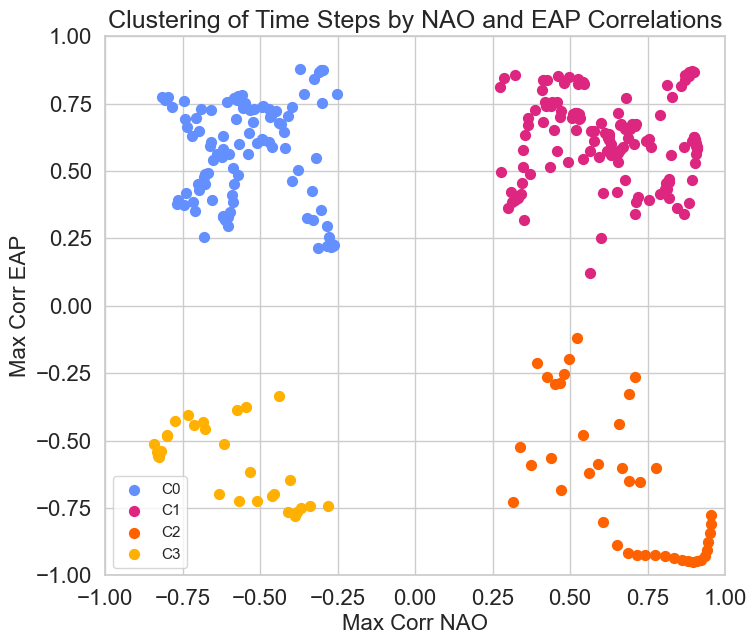

In [70]:
# --- Plot cluster definitions ---
style   = sns.set_style("whitegrid")

plt.figure(figsize=(8, 7))
c1 = plt.scatter(df['max_corr_nao'][df['cluster'] == 0], df['max_corr_eap'][df['cluster'] == 0], c=c_1, s=50, label = 'C0')
c2 = plt.scatter(df['max_corr_nao'][df['cluster'] == 1], df['max_corr_eap'][df['cluster'] == 1], c=c_2, s=50, label = 'C1')
c3 = plt.scatter(df['max_corr_nao'][df['cluster'] == 2], df['max_corr_eap'][df['cluster'] == 2], c=c_3, s=50, label = 'C2')
c4 = plt.scatter(df['max_corr_nao'][df['cluster'] == 3], df['max_corr_eap'][df['cluster'] == 3], c=c_4, s=50, label = 'C3')

plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xlabel('Max Corr NAO', fontsize = 16)
plt.ylabel('Max Corr EAP',fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend()
plt.title('Clustering of Time Steps by NAO and EAP Correlations',fontsize = 18)
plt.grid(True)
plt.show()

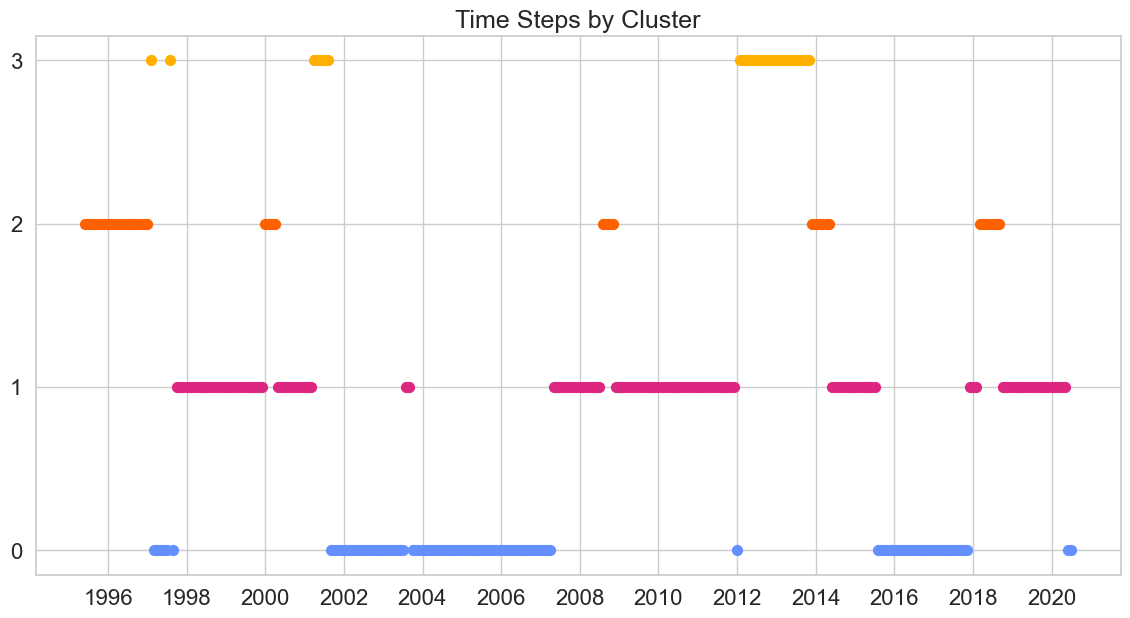

In [88]:
# --- Plot time series of clusters ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['cluster'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['cluster'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['cluster'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['cluster'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['cluster'][df['cluster'] == 3],c=c_4, s=50)

plt.title('Time Steps by Cluster',fontsize = 18)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,4),fontsize = 16)

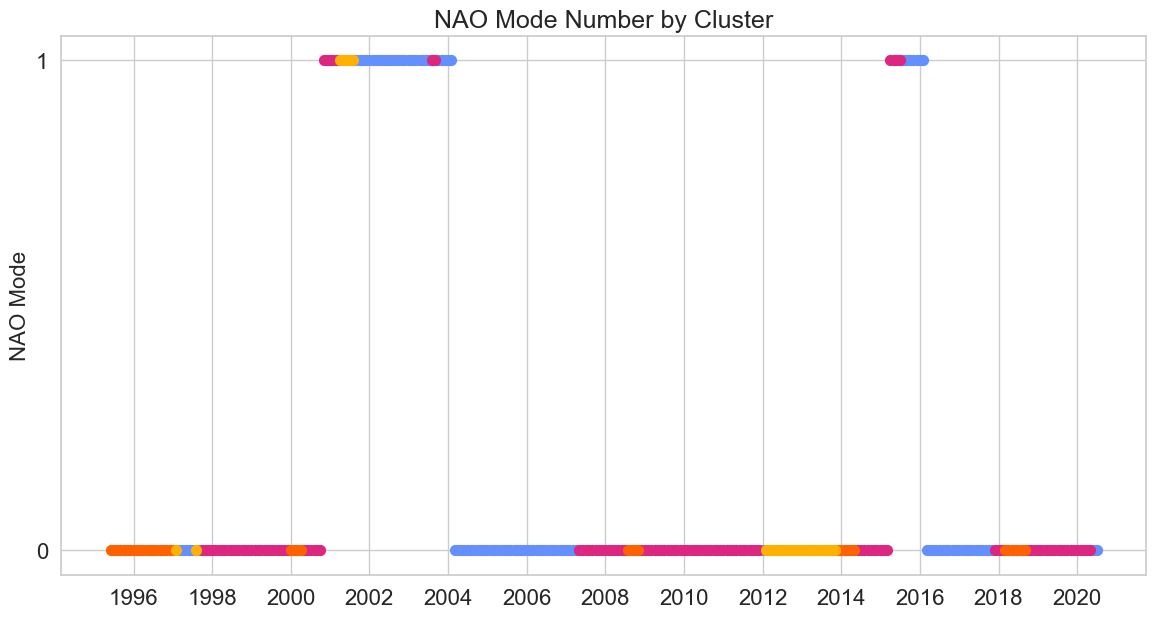

In [106]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['nao_mode_num'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['nao_mode_num'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['nao_mode_num'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['nao_mode_num'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['nao_mode_num'][df['cluster'] == 3],c=c_4, s=50)
plt.title('NAO Mode Number by Cluster',fontsize = 18)
plt.ylabel('NAO Mode', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,2),fontsize = 16)

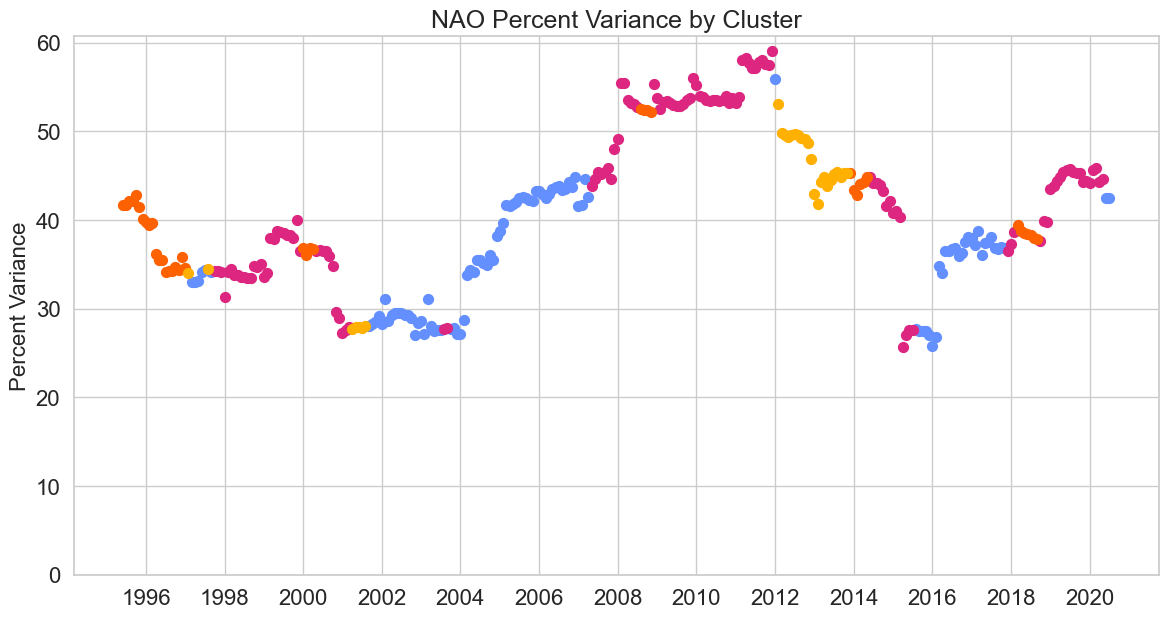

In [109]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['per_var_nao'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['per_var_nao'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['per_var_nao'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['per_var_nao'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['per_var_nao'][df['cluster'] == 3],c=c_4, s=50)
plt.title('NAO Percent Variance by Cluster',fontsize = 18)
plt.ylabel('Percent Variance', fontsize = 16)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,61,10),fontsize = 16)

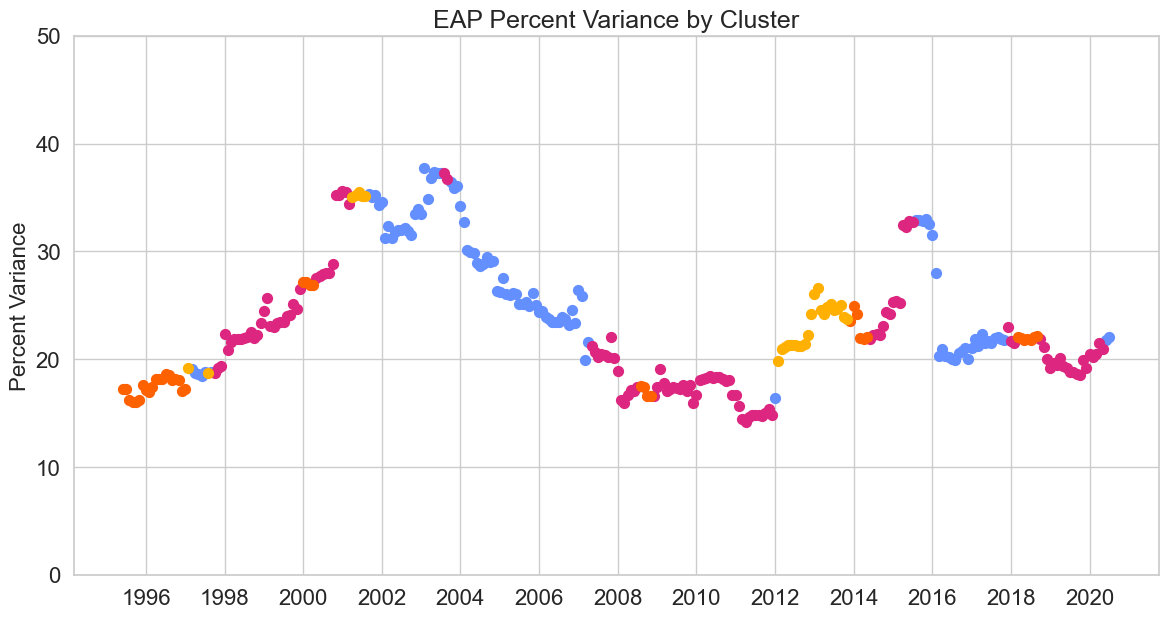

In [110]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['per_var_eap'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['per_var_eap'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['per_var_eap'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['per_var_eap'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['per_var_eap'][df['cluster'] == 3],c=c_4, s=50)
plt.title('EAP Percent Variance by Cluster',fontsize = 18)
plt.ylabel('Percent Variance', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(0,51,10),fontsize = 16)

In [111]:
df['total_per_var'] = df['per_var_eap'] + df['per_var_nao']

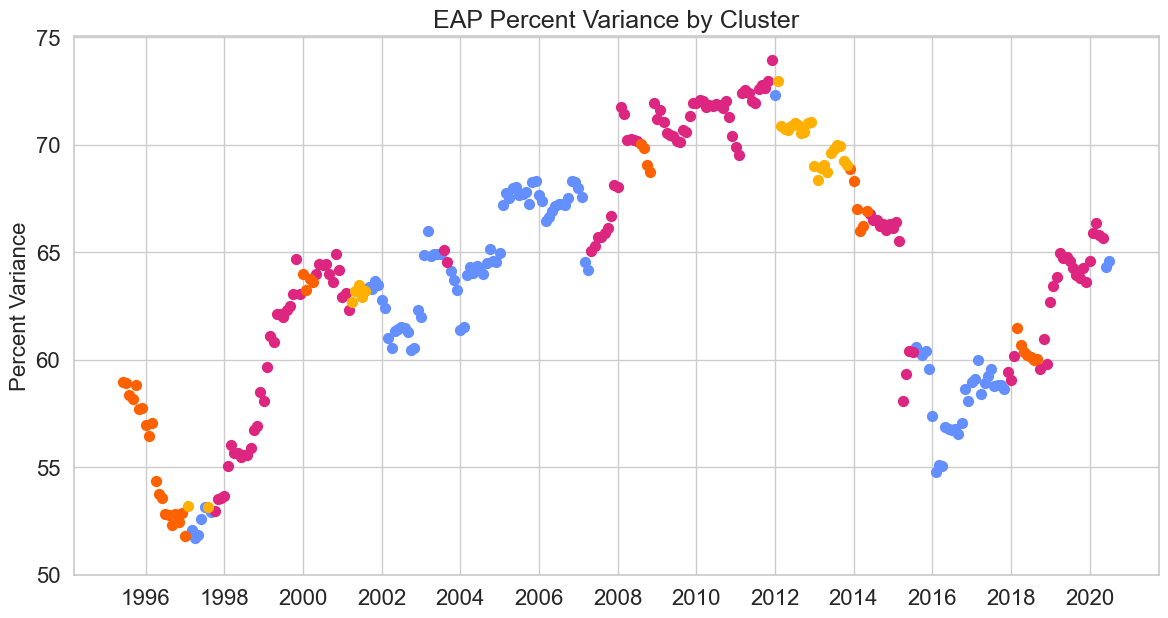

In [115]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['total_per_var'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['total_per_var'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['total_per_var'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['total_per_var'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['total_per_var'][df['cluster'] == 3],c=c_4, s=50)
plt.title('EAP Percent Variance by Cluster',fontsize = 18)
plt.ylabel('Percent Variance', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(50,80,5),fontsize = 16)

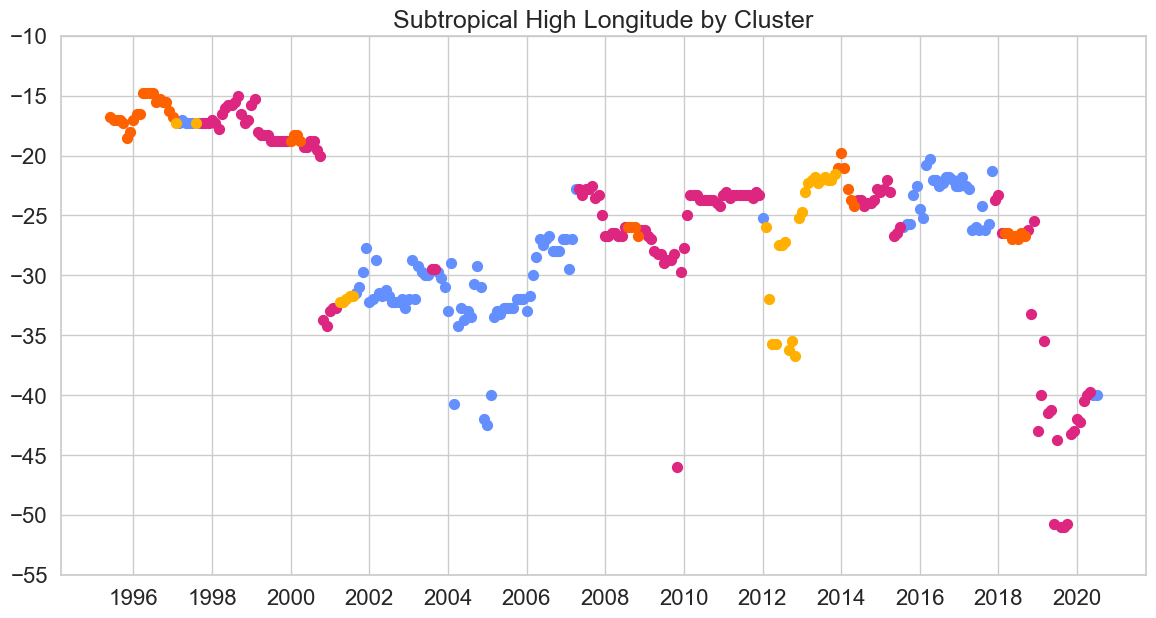

In [99]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['subtrop_high_long'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['subtrop_high_long'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['subtrop_high_long'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['subtrop_high_long'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['subtrop_high_long'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Subtropical High Longitude by Cluster',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-55,-9,5),fontsize = 16)

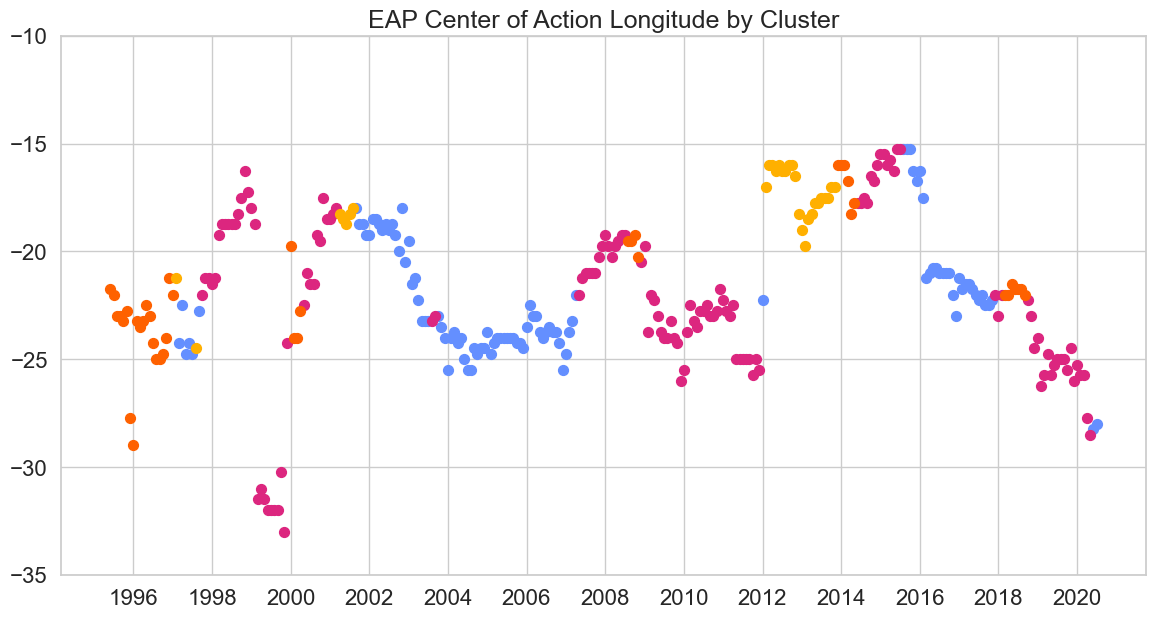

In [96]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['eap_long'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['eap_long'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['eap_long'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['eap_long'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['eap_long'][df['cluster'] == 3],c=c_4, s=50)
plt.title('EAP Center of Action Longitude by Cluster',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-35,-9,5),fontsize = 16)

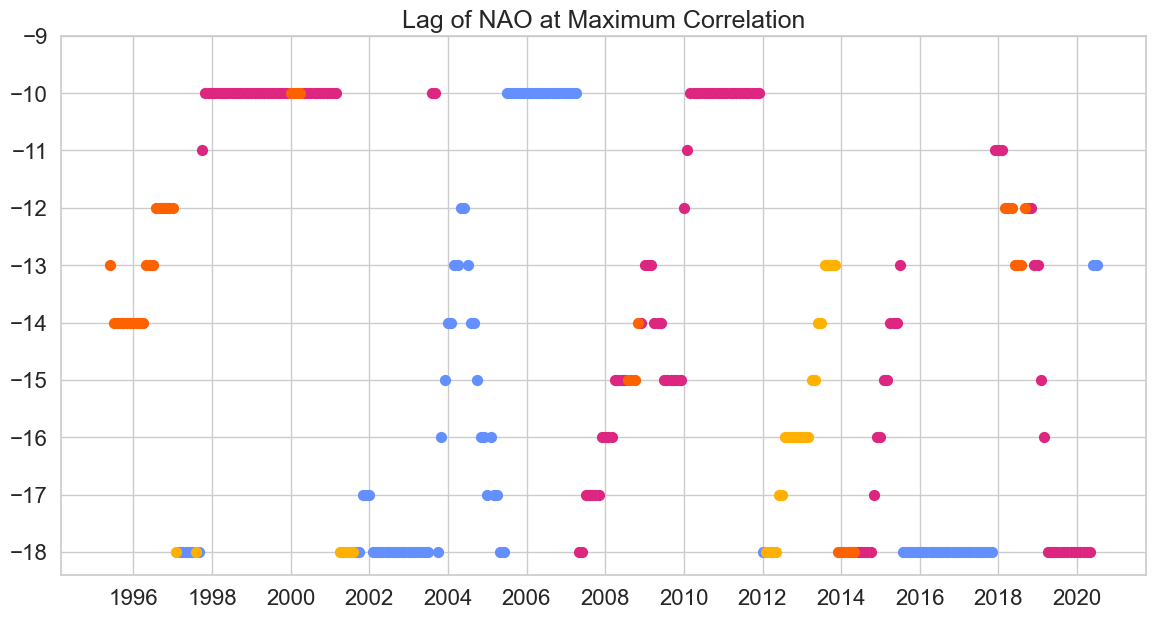

In [97]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_lag_nao'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_lag_nao'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_lag_nao'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_lag_nao'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_lag_nao'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Lag of NAO at Maximum Correlation',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-18,-8),fontsize = 16)

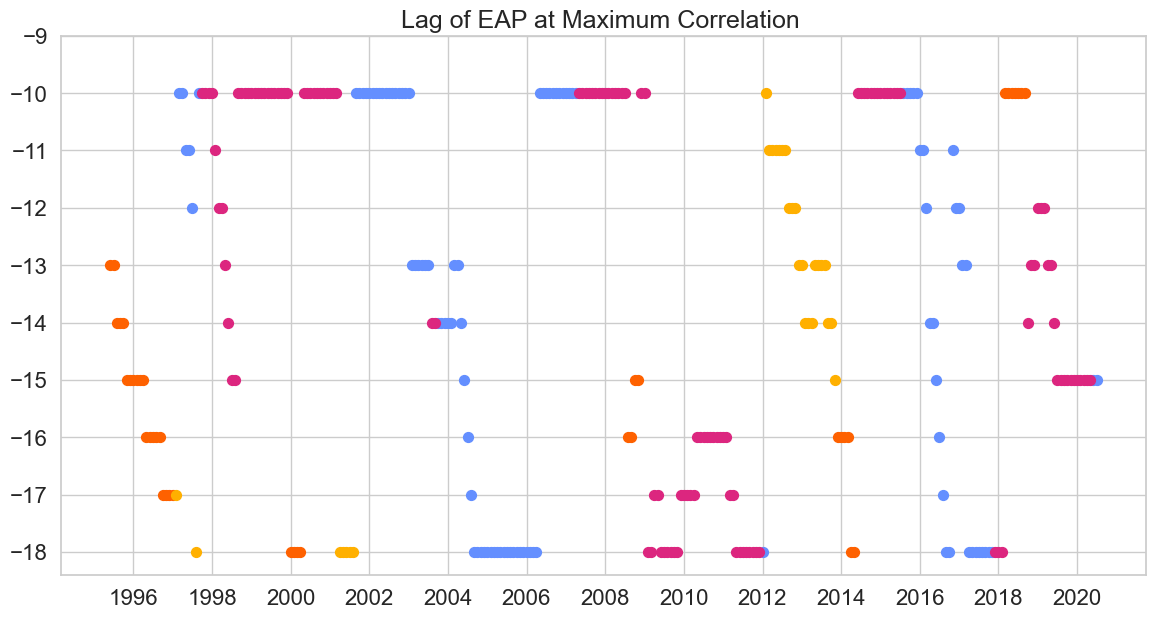

In [98]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_lag_eap'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_lag_eap'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_lag_eap'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_lag_eap'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_lag_eap'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Lag of EAP at Maximum Correlation ',fontsize = 18)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-18,-8),fontsize = 16)

In [100]:
df

,time_centered,nao_mode_num,per_var_nao,per_var_eap,subtrop_high_long,eap_long,max_corr_nao,max_lag_nao,max_corr_eap,max_lag_eap,cluster
0,1995-06-01,0,41.709950,17.238930,-16.75,-21.75,0.955223,-13,-0.775847,-13,2
1,1995-07-01,0,41.702204,17.192909,-17.00,-22.00,0.953149,-14,-0.810497,-13,2
2,1995-08-01,0,42.142612,16.239288,-17.00,-23.00,0.950742,-14,-0.844825,-14,2
3,1995-09-01,0,42.102664,16.062841,-17.00,-23.00,0.945850,-14,-0.877494,-14,2
4,1995-10-01,0,42.790082,16.014431,-17.25,-23.25,0.941274,-14,-0.907669,-14,2
...,...,...,...,...,...,...,...,...,...,...,...
297,2020-03-01,0,45.840565,20.519569,-40.50,-25.75,0.478924,-18,0.825664,-15,1
298,2020-04-01,0,44.300211,21.505063,-40.00,-27.75,0.412216,-18,0.837355,-15,1
299,2020-05-01,0,44.673129,20.985066,-39.75,-28.50,0.321635,-18,0.854685,-15,1
300,2020-06-01,0,42.498138,21.827879,-40.00,-28.25,-0.311290,-13,0.868420,-15,0


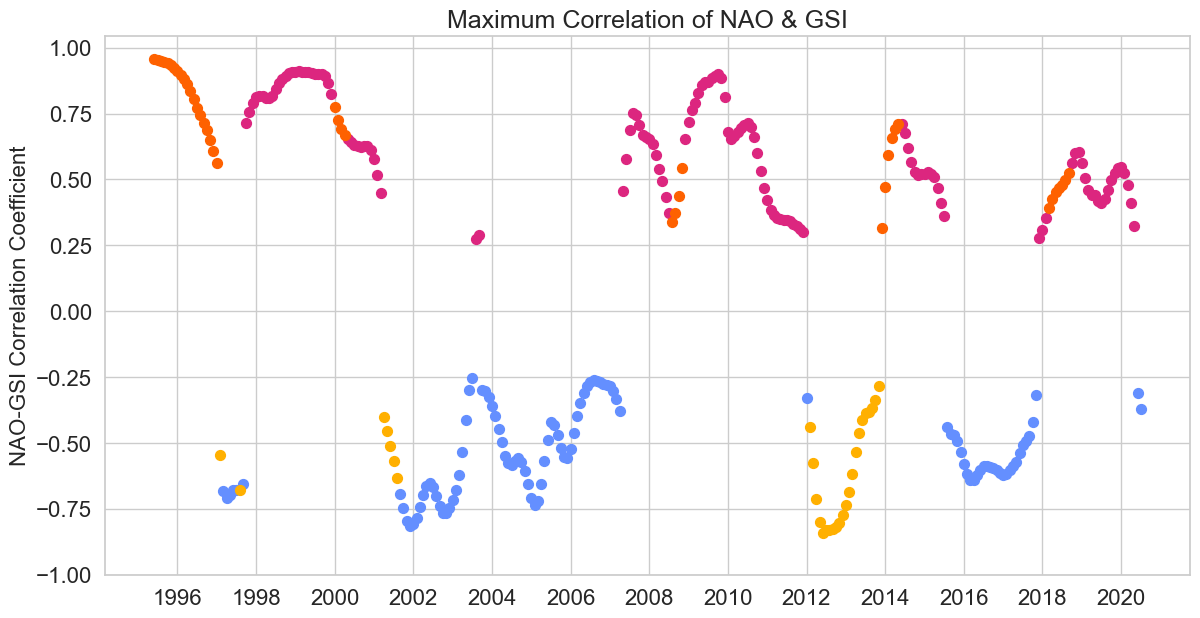

In [108]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_corr_nao'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_corr_nao'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_corr_nao'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_corr_nao'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_corr_nao'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Maximum Correlation of NAO & GSI',fontsize = 18)
plt.ylabel('NAO-GSI Correlation Coefficient', fontsize = 16)

xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-1,1.1,0.25),fontsize = 16)

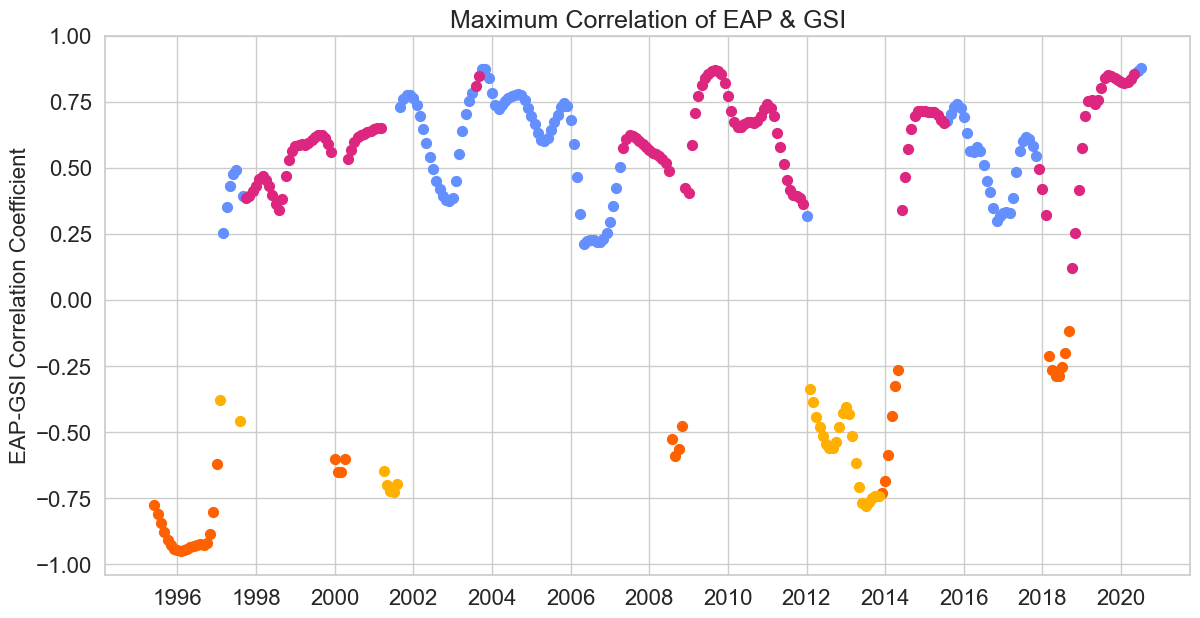

In [107]:
# --- NAO Phase by Cluster ---
style   = sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

plt.scatter(df['time_centered'], df['max_corr_eap'], s = 1)
plt.scatter(df['time_centered'][df['cluster'] == 0], df['max_corr_eap'][df['cluster'] == 0],c=c_1, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 1], df['max_corr_eap'][df['cluster'] == 1],c=c_2, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 2], df['max_corr_eap'][df['cluster'] == 2],c=c_3, s=50)
plt.scatter(df['time_centered'][df['cluster'] == 3], df['max_corr_eap'][df['cluster'] == 3],c=c_4, s=50)
plt.title('Maximum Correlation of EAP & GSI',fontsize = 18)
plt.ylabel('EAP-GSI Correlation Coefficient', fontsize = 16)
xtix = plt.xticks(df['time_centered'][7::24], labels= np.arange(1996,2021,2),fontsize = 16)
ytix = plt.yticks(np.arange(-1,1.1,0.25),fontsize = 16)

In [117]:
df.to_csv(data_path + 'composite_logs_with_clusters.csv')